In [123]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
eps = 1e-3
inc_ang = (30+eps)*(np.pi/180)   # radian
azi_ang = (0+eps)*(np.pi/180)   # radian

order_N = 15

# geometry
h = 1000 #nm
grating_period = 1000 # nm
n = 1000

x_plot = torch.linspace(-grating_period/2,grating_period/2,501,device=device)
y_plot = torch.clone(x_plot)
z_plot = torch.linspace(-0.5*h,1.1*h,501,device=device)

wavelength = torch.tensor(700+1e-3)
wavelengths = torch.linspace(300, 1100, 1601, dtype=float)+1e-3 # for stability

#Sanity check of staircase approximation
num_layers = 10

config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period,h=h,order_N=order_N, order_N_y=order_N, \
    nx = n, ny = n, n_layers = num_layers, subpixel = True, add_reflector = True, reflector_type = 'pec', inc_ang = inc_ang, azi_ang = azi_ang)

params_x = torch.tensor([[40,0] for i in range(10)], dtype=geo_dtype, device=device)
#params_y = torch.tensor([[0., 0.]], dtype=geo_dtype, device=device)
params_y = None

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Testing and plotting

In [124]:
wavelengths

tensor([ 300.0010,  300.5010,  301.0010,  ..., 1099.0010, 1099.5010,
        1100.0010], dtype=torch.float64)

In [125]:
sim, sine_eps, A_film, A_grating, Reflectance, Transmittance, P_abs_film, P_abs_grating \
    = get_absorptance(params_x,params_y,wavelength,config)

In [126]:
polarization = [1,0]

(<Figure size 800x400 with 2 Axes>,
 <Axes: title={'center': 'Staircase Permittivity Profile (xz at 0.0nm)'}, xlabel='x (nm)', ylabel='z (nm)'>)

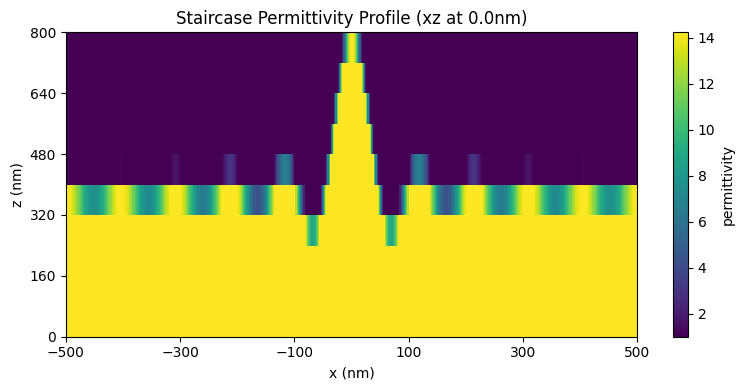

In [128]:
plot_fields(sim, x_plot, z_plot, wavelength, polarization, params_x, params_y, config, field="sine_eps", thickness=2,y_plot=y_plot, slice_plane='xz', slice_val=0)

In [109]:
A_film + A_grating + Reflectance + Transmittance

tensor([1.0000, 1.0000], device='cuda:0')

In [110]:
A_film, A_grating, Reflectance, Transmittance

(tensor([0.2421, 0.2381], device='cuda:0'),
 tensor([0.0083, 0.0088], device='cuda:0'),
 tensor([0.7496, 0.7531], device='cuda:0'),
 tensor([-2.3227e-07, -2.9200e-07], device='cuda:0'))

In [111]:
def objective_function(params):
    """
    Objective function to minimize: negative weighted absorptance.
    """
    transformed = torch.stack((torch.exp(params[:,0]), 2*torch.atan(params[:,1])), dim=-1)
    loss = torch.zeros(1).cuda()
    #for wavelength in wavelengths:
    #    A_film, A_grating = \
    #        get_absorptance(transformed,wavelength,inc_ang,azi_ang,grating_period,grating_period,h,order_N,n_layers=num_layers,nx=nx, ny=nx,add_reflector=True,reflector_type='pec',subpixel=True)[2:4]
    #    loss += -A_film[0] - A_film[1]
    #for inc_ang in np.array([0,10,20,30])+eps:
    #    A_film, A_grating = \
    #        get_absorptance(transformed,wavelength,inc_ang,azi_ang,grating_period,grating_period,h,order_N,n_layers=num_layers,nx=nx, ny=nx,add_reflector=True,reflector_type='pec',subpixel=True)[2:4]
    #    loss += -A_film[0]-A_film[1]
    A_film, A_grating = \
        get_absorptance(transformed,wavelength,inc_ang,azi_ang,grating_period,grating_period,h,order_N,n_layers=num_layers,nx=nx, ny=nx,add_reflector=True,reflector_type='pec',subpixel=True)[2:4]
    loss += -A_film[0]-A_film[1]
    #print(A_film)
    return loss

In [ ]:
#find optimal parameters
init_params_x = torch.tensor([[np.log(40),0] if i==0 else [-100,0] for i in range(10)],dtype=geo_dtype,device=device,requires_grad=True)
opt = torch.optim.AdamW([init_params], lr=1e-1,weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)

pbar = tqdm(range(500), desc="Optimizing Parameters")
best_loss = float('inf')

for it in pbar:
    opt.zero_grad()
    loss = objective_function(init_params)
    loss.backward()
    opt.step()
    scheduler.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_params = init_params.detach().clone()
    pbar.set_description(f"Iteration {it}: Loss = {loss.item():.4f} - lr = {scheduler.get_last_lr()[0]:.4f}")

In [ ]:
best_params

In [ ]:
best_params = torch.stack((torch.exp(best_params[:,0]), 2*torch.atan(best_params[:,1])), dim=-1).detach()

In [ ]:
best_params

In [ ]:
sim, sine_eps, A_film, A_grating, Reflectance, Transmittance, P_abs_film, P_abs_grating \
    = get_absorptance(best_params,wavelength,inc_ang,azi_ang,grating_period,grating_period,h,order_N,n_layers=num_layers,nx=nx, ny=nx,add_reflector=True,reflector_type='pec',subpixel=True)

## Absorptance curves

### Num layers

In [ ]:
layer_counts = [1, 2, 3, 5, 10, 15, 20, 25, 50, 100, 150, 250, 251]

In [ ]:
simulation_results = {}

for num_layers in layer_counts:
    print(f'simulating absorptance curve for {num_layers} layers')
    config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period, h=h, order_N=order_N, order_N_y=order_N, nx=nx, ny=nx, n_layers=num_layers, subpixel=True, add_reflector=True, reflector_type='pec', inc_ang=inc_ang, azi_ang=azi_ang)
    absorptances_film, absorptances_grating = get_absorptance_curve(params_x, params_y, wavelengths, config)

    simulation_results[num_layers] = {
        'absorptances_film': absorptances_film.cpu(),
        'absorptances_grating': absorptances_grating.cpu(),
        'wavelengths': wavelengths.cpu(),
        'params': params_x.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_num_layers_sinc.pt')

In [ ]:
simulation_results = {}

for num_layers in layer_counts:
    print(f'simulating absorptance curve for {num_layers} layers')
    config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period, h=h, order_N=order_N, order_N_y=order_N, nx=nx, ny=nx, n_layers=num_layers, subpixel=False, add_reflector=True, reflector_type='pec', inc_ang=inc_ang, azi_ang=azi_ang)
    absorptances_film, absorptances_grating = get_absorptance_curve(params_x, params_y, wavelengths, config)

    simulation_results[num_layers] = {
        'absorptances_film': absorptances_film.cpu(),
        'absorptances_grating': absorptances_grating.cpu(),
        'wavelengths': wavelengths.cpu(),
        'params': params_x.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_num_layers_no_smoothing_sinc.pt')

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_num_layers.pt', weights_only=False)
layer_counts = sorted(list(results.keys()))

best_layer_count = layer_counts[-1]
best_abs = results[best_layer_count]['absorptances_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[num_layers]['absorptances_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')         
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Smoothing')
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig')
plt.show()

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_num_layers_no_smoothing.pt', weights_only=False)
layer_counts = sorted(list(results.keys()))

best_layer_count = layer_counts[-1]
best_abs = results[best_layer_count]['absorptances_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[num_layers]['absorptances_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('No Smoothing')
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig_no_smoothing')
plt.show()

In [ ]:
# Load both saved simulation datasets
results_no = torch.load('../Data/rcwa_convergence_data_num_layers_no_smoothing.pt', weights_only=False)
results_sm = torch.load('../Data/rcwa_convergence_data_num_layers.pt', weights_only=False)

layer_counts = sorted(list(results_no.keys()))
best_layer_count = layer_counts[-1]

# Baselines for each dataset
best_abs_no = results_no[best_layer_count]['absorptances_film']
best_abs_sm = results_sm[best_layer_count]['absorptances_film']

# Pre-calculate mean errors
mean_errors_p_no, mean_errors_s_no = [], []
mean_errors_p_sm, mean_errors_s_sm = [], []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    plot_layers.append(num_layers)
    
    # Calculate No Smoothing errors
    curr_abs_no = results_no[num_layers]['absorptances_film']
    mean_errors_p_no.append(torch.mean(torch.abs((curr_abs_no[:, 0] - best_abs_no[:, 0]))).item())
    mean_errors_s_no.append(torch.mean(torch.abs((curr_abs_no[:, 1] - best_abs_no[:, 1]))).item())
    
    # Calculate Smoothing errors
    curr_abs_sm = results_sm[num_layers]['absorptances_film']
    mean_errors_p_sm.append(torch.mean(torch.abs((curr_abs_sm[:, 0] - best_abs_sm[:, 0]))).item())
    mean_errors_s_sm.append(torch.mean(torch.abs((curr_abs_sm[:, 1] - best_abs_sm[:, 1]))).item())

# Create a 3x2 grid
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
(ax1_p, ax1_s), (ax2_p, ax2_s), (ax3_p, ax3_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs_no = results_no[num_layers]['absorptances_film']
    curr_abs_sm = results_sm[num_layers]['absorptances_film']
    
    # Row 1: Plot spectra (No Smoothing)
    ax1_p.plot(wavelengths.cpu(), curr_abs_no[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs_no[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    
    # Row 2: Plot spectra (With Smoothing)
    ax2_p.plot(wavelengths.cpu(), curr_abs_sm[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax2_s.plot(wavelengths.cpu(), curr_abs_sm[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)

# --- Format Row 1 (No Smoothing Spectra) ---
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Spectra (No Smoothing)\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Spectra (No Smoothing)\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')

# --- Format Row 2 (With Smoothing Spectra) ---
ax2_p.set_xlabel('Wavelength (nm)')
ax2_p.set_ylabel('Absorptance')
ax2_p.set_title('p-Polarization Spectra (With Smoothing)')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.legend(title='Staircase Resolution', loc='best', fontsize='small')

ax2_s.set_xlabel('Wavelength (nm)')
ax2_s.set_ylabel('Absorptance')
ax2_s.set_title('s-Polarization Spectra (With Smoothing)')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.legend(title='Staircase Resolution', loc='best', fontsize='small')

# --- Format Row 3 (Mean Error Convergence Comparison) ---
# p-polarization
ax3_p.plot(plot_layers, mean_errors_p_no, marker='o', linestyle='-', color='blue', label='No Smoothing')
ax3_p.plot(plot_layers, mean_errors_p_sm, marker='^', linestyle='--', color='dodgerblue', label='With Smoothing')
ax3_p.set_xlabel('Number of Layers')
ax3_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax3_p.set_title('p-Polarization Convergence Trend')
ax3_p.grid(True, linestyle='--', alpha=0.6)
ax3_p.set_yscale('log')
ax3_p.set_xscale('log')
ax3_p.legend()

# s-polarization
ax3_s.plot(plot_layers, mean_errors_s_no, marker='s', linestyle='-', color='red', label='No Smoothing')
ax3_s.plot(plot_layers, mean_errors_s_sm, marker='^', linestyle='--', color='darkorange', label='With Smoothing')
ax3_s.set_xlabel('Number of Layers')
ax3_s.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax3_s.set_title('s-Polarization Convergence Trend')
ax3_s.grid(True, linestyle='--', alpha=0.6)
ax3_s.set_yscale('log')
ax3_s.set_xscale('log')
ax3_s.legend()

fig.suptitle('RCWA Convergence: Smoothing vs No Smoothing', fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_3x2_comparison.png')
plt.show()

#### compare to comsol

In [ ]:
# Load the COMSOL data (skipping the '%' header lines)
comsol_data = np.loadtxt('/home/an/Documents/COMSOL/mph files/Exported data/Absorptance curve with IBC.txt', comments='%')
comsol_wavelengths = comsol_data[::, 0]
comsol_abs = comsol_data[::, 4]

# Create a single plot for the s-polarization comparison
fig, ax = plt.subplots(figsize=(8, 6))

# Plot RCWA (index 1 is s-pol) and COMSOL data

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances_film']
    
    ax.plot(wavelengths.cpu().numpy(), curr_abs[:, 1].cpu().numpy(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5,alpha=0.8)
ax.plot(comsol_wavelengths, comsol_abs, label='COMSOL FEM', color='black',alpha=0.8, linestyle='--', linewidth=1.5)

# Format the plot
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorptance')
ax.set_title('RCWA vs COMSOL (s-Polarization)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
#ax.set_yscale('log')

fig.tight_layout()
fig.savefig('../Data/RCWA_vs_COMSOL_spol_comparison.png')
plt.show()

In [ ]:
# Create a single plot for the s-polarization comparison
fig, ax = plt.subplots(figsize=(8, 6))

# Plot RCWA (index 1 is s-pol) and COMSOL data

for idx, num_layers in enumerate(layer_counts):
    #if num_layers == 250:
        curr_abs = results[num_layers]['absorptances_film']
        ax.plot(wavelengths.cpu().numpy(), np.abs(comsol_abs-curr_abs[:, 1].cpu().numpy()), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5,alpha=0.8)
ax.plot(comsol_wavelengths, comsol_abs-comsol_abs, label='COMSOL FEM', color='black',alpha=0.8, linestyle='--', linewidth=1.5)

# Format the plot
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorptance')
ax.set_title('RCWA vs COMSOL (s-Polarization) error plot vs comsol FEM')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
ax.set_yscale('log')

fig.tight_layout()
fig.savefig('../Data/RCWA_vs_COMSOL_spol_comparison.png')
plt.show()

In [ ]:
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    curr_abs = results[num_layers]['absorptances_film'].cpu().numpy()
    
    err_s = np.mean(np.abs((curr_abs[:, 1] - comsol_abs))).item()
    
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(plot_layers, mean_errors_s, marker='o', linestyle='-', color='red')
ax.set_xlabel('Number of Layers')
ax.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax.set_title('s-Polarization Convergence Trend')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_yscale('log')
ax.set_xscale('log')

### *Fourier* Order

In [ ]:
Order_Ns = [1, 5, 10, 20, 35, 50, 100]

In [ ]:
simulation_results = {}
num_layers = 15

for order_N in Order_Ns:
    print(f'simulating absorptance curve for {order_N} fourier orders')
    config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period, h=h, order_N=order_N, order_N_y=order_N, nx=nx, ny=nx, n_layers=num_layers, subpixel=True, add_reflector=True, reflector_type='pec', inc_ang=inc_ang, azi_ang=azi_ang)
    absorptances_film, absorptances_grating = get_absorptance_curve(params_x, params_y, wavelengths, config)

    simulation_results[num_layers] = {
        'absorptances_film': absorptances_film.cpu(),
        'absorptances_grating': absorptances_grating.cpu(),
        'wavelengths': wavelengths.cpu(),
        'params': params_x.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_order_N.pt')

In [ ]:
simulation_results = {}
num_layers = 15

for order_N in Order_Ns:
    print(f'simulating absorptance curve for {order_N} fourier orders')
    config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period, h=h, order_N=order_N, order_N_y=order_N, nx=nx, ny=nx, n_layers=num_layers, subpixel=False, add_reflector=True, reflector_type='pec', inc_ang=inc_ang, azi_ang=azi_ang)
    absorptances_film, absorptances_grating = get_absorptance_curve(params_x, params_y, wavelengths, config)

    simulation_results[num_layers] = {
        'absorptances_film': absorptances_film.cpu(),
        'absorptances_grating': absorptances_grating.cpu(),
        'wavelengths': wavelengths.cpu(),
        'params': params_x.cpu()
    }
    
# Save results to disk to decouple simulation from plotting
torch.save(simulation_results, '../Data/rcwa_convergence_data_order_N_no_smoothing.pt')

In [ ]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_order_N.pt', weights_only=False)
order_Ns = sorted(list(results.keys()))

best_order = order_Ns[-1]
best_abs = results[best_order]['absorptances_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_orders = []

for order_N in order_Ns:
    if order_N == best_order:
        continue
    curr_abs = results[order_N]['absorptances_film']
    
    # Calculate error to the highest Fourier order
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]) / (best_abs[:, 0] + 1e-12))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]) / (best_abs[:, 1] + 1e-12))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_orders.append(order_N)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order_N in enumerate(order_Ns):
    curr_abs = results[order_N]['absorptances_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)

# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Fourier Orders', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Fourier Orders', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_orders, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Fourier Orders (N)')
ax2_p.set_ylabel(f'Mean Error (vs N={best_order})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_orders, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Fourier Orders (N)')
ax2_s.set_ylabel(f'Mean Error (vs N={best_order})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.tight_layout()
fig.savefig('../Data/Order_N_convergence_fig')
plt.show()